<a href="https://colab.research.google.com/github/nagaraj1696/DLNN_exps_R24EV028/blob/main/DLNN_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Deleted corrupted images: 1590
Found 23410 files belonging to 2 classes.
Using 18728 files for training.
Found 23410 files belonging to 2 classes.
Using 4682 files for validation.
Classes: ['Cat', 'Dog']
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 78s 103ms/step - accuracy: 0.9825 - loss: 0.0508 - val_accuracy: 0.9887 - val_loss: 0.0334
Epoch 2/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 31s 53ms/step - accuracy: 0.9895 - loss: 0.0283 - val_accuracy: 0.9891 - val_loss: 0.0315
Epoch 3/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 42s 55ms/step - accuracy: 0.9921 - loss: 0.0212 - val_accuracy: 0.9799 - val_loss: 0.0609
Epoch 4/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 32s 54ms/step - accuracy: 0.9953 - loss: 0.0145 - val_accuracy: 0.9833 - val_loss: 0.0491
Epoch 5/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 32s 54ms/step - accuracy: 0.9965 - loss: 0.0102 - val_accuracy: 0.9880 - val_loss: 0.0375
147/147 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.9880 - loss: 0.0375
Accuracy before fine-tuning: 0.9880393147468567
Epoch 1/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 60s 80ms/step - accuracy: 0.9815 - loss: 0.0509 - val_accuracy: 0.9921 - val_loss: 0.0283
Epoch 2/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 32s 55ms/step - accuracy: 0.9871 - loss: 0.0355 - val_accuracy

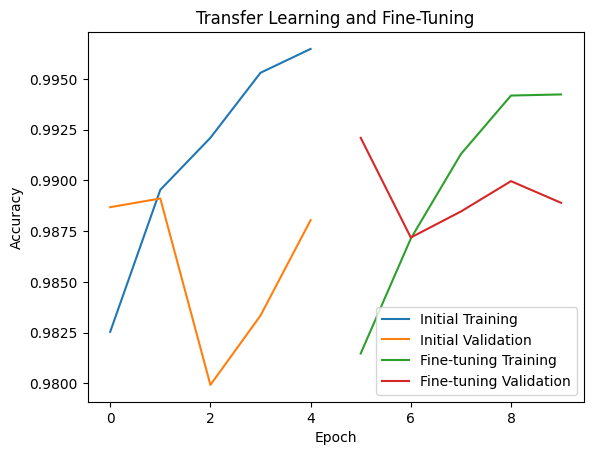

In [1]:
# ============================================================
# TRANSFER LEARNING USING MOBILENETV2
# Binary Image Classification: Cats vs Dogs
# ============================================================

# ------------------------------------------------------------
# 1. Import libraries
# ------------------------------------------------------------

import tensorflow as tf
import os
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input


# ------------------------------------------------------------
# 2. Download Cats vs Dogs dataset
# ------------------------------------------------------------

!wget -q https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip

!unzip -q kagglecatsanddogs_5340.zip


# ------------------------------------------------------------
# 3. Remove corrupted images
# ------------------------------------------------------------

num_skipped = 0

for folder_name in ("Cat", "Dog"):

    folder_path = os.path.join("PetImages", folder_name)

    for fname in os.listdir(folder_path):

        fpath = os.path.join(folder_path, fname)

        try:
            with open(fpath, "rb") as fobj:
                is_jfif = b"JFIF" in fobj.peek(10)

        except Exception:
            is_jfif = False

        if not is_jfif:
            num_skipped += 1
            os.remove(fpath)

print("Deleted corrupted images:", num_skipped)


# ------------------------------------------------------------
# 4. Load dataset
# ------------------------------------------------------------

train_dataset = tf.keras.utils.image_dataset_from_directory(
    "PetImages",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(224, 224),
    batch_size=32
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    "PetImages",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(224, 224),
    batch_size=32
)

print("Classes:", train_dataset.class_names)


# ------------------------------------------------------------
# 5. Preprocess images for MobileNetV2
# ------------------------------------------------------------

train_dataset = train_dataset.map(
    lambda x, y: (preprocess_input(x), y)
)

validation_dataset = validation_dataset.map(
    lambda x, y: (preprocess_input(x), y)
)


# ------------------------------------------------------------
# 6. Load pre-trained MobileNetV2
# ------------------------------------------------------------

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)


# ------------------------------------------------------------
# 7. Freeze the pre-trained layers
# ------------------------------------------------------------

base_model.trainable = False


# ------------------------------------------------------------
# 8. Add custom classification head
# ------------------------------------------------------------

model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    Dense(
        128,
        activation="relu"
    ),

    Dense(
        1,
        activation="sigmoid"
    )
])


# ------------------------------------------------------------
# 9. Compile model
# ------------------------------------------------------------

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


# ------------------------------------------------------------
# 10. Display model architecture
# ------------------------------------------------------------

model.summary()


# ------------------------------------------------------------
# 11. Train classification head
# ------------------------------------------------------------

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=5
)


# ------------------------------------------------------------
# 12. Evaluate before fine-tuning
# ------------------------------------------------------------

loss, accuracy = model.evaluate(validation_dataset)

print("Accuracy before fine-tuning:", accuracy)


# ============================================================
# FINE-TUNING
# ============================================================


# ------------------------------------------------------------
# 13. Unfreeze the MobileNetV2
# ------------------------------------------------------------

base_model.trainable = True


# ------------------------------------------------------------
# 14. Freeze most layers and fine-tune last few layers
# ------------------------------------------------------------

for layer in base_model.layers[:-20]:
    layer.trainable = False


# ------------------------------------------------------------
# 15. Recompile with smaller learning rate
# ------------------------------------------------------------

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.00001
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


# ------------------------------------------------------------
# 16. Fine-tune model
# ------------------------------------------------------------

history_fine = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=5
)


# ------------------------------------------------------------
# 17. Final evaluation
# ------------------------------------------------------------

loss, accuracy = model.evaluate(validation_dataset)

print("Final Test Loss:", loss)
print("Final Test Accuracy:", accuracy)


# ------------------------------------------------------------
# 18. Plot accuracy
# ------------------------------------------------------------

plt.plot(history.history["accuracy"], label="Initial Training")
plt.plot(history.history["val_accuracy"], label="Initial Validation")

plt.plot(
    range(
        len(history.history["accuracy"]),
        len(history.history["accuracy"]) +
        len(history_fine.history["accuracy"])
    ),
    history_fine.history["accuracy"],
    label="Fine-tuning Training"
)

plt.plot(
    range(
        len(history.history["val_accuracy"]),
        len(history.history["val_accuracy"]) +
        len(history_fine.history["val_accuracy"])
    ),
    history_fine.history["val_accuracy"],
    label="Fine-tuning Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Transfer Learning and Fine-Tuning")

plt.legend()
plt.show()

Found 23410 files belonging to 2 classes.
Using 18728 files for training.
Found 23410 files belonging to 2 classes.
Using 4682 files for validation.
Classes: ['Cat', 'Dog']
Epoch 1/5


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


586/586 ━━━━━━━━━━━━━━━━━━━━ 46s 68ms/step - accuracy: 0.5522 - loss: 3.7728 - val_accuracy: 0.5809 - val_loss: 0.6715
Epoch 2/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 72s 60ms/step - accuracy: 0.6105 - loss: 0.6618 - val_accuracy: 0.6294 - val_loss: 0.6377
Epoch 3/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 40s 68ms/step - accuracy: 0.6791 - loss: 0.6064 - val_accuracy: 0.6583 - val_loss: 0.6877
Epoch 4/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 36s 60ms/step - accuracy: 0.7227 - loss: 0.5472 - val_accuracy: 0.7033 - val_loss: 0.6200
Epoch 5/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 41s 59ms/step - accuracy: 0.7631 - loss: 0.4880 - val_accuracy: 0.6950 - val_loss: 0.6686
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 92s 137ms/step - accuracy: 0.9836 - loss: 0.0541 - val_accuracy: 0.9863 - val_loss: 0.0335
Epoch 2/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 71s 120ms/step - accuracy: 0.9907 - loss: 0.0260 - val_accuracy: 0.9900 - val_loss: 0.0255
Epoch 3/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 76s 130ms/step 

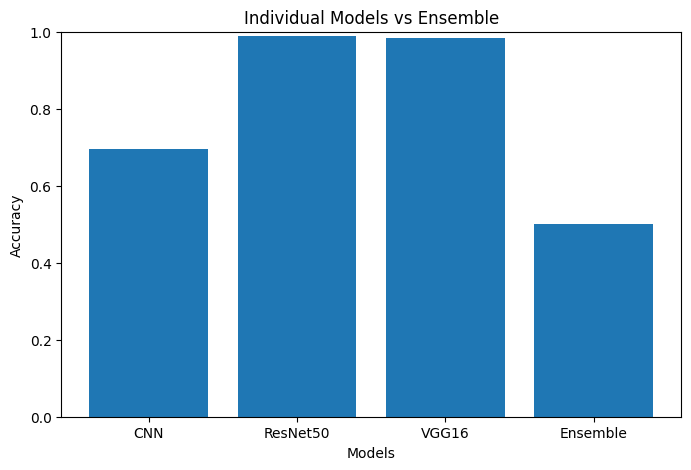

In [2]:
# ============================================================
# ENSEMBLE MODELING
# Customized CNN + ResNet50 + VGG16
# Binary Classification: Cats vs Dogs
# ============================================================

# ------------------------------------------------------------
# 1. Import libraries
# ------------------------------------------------------------

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense,
    Dropout, GlobalAveragePooling2D
)

from tensorflow.keras.applications import ResNet50, VGG16
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess


# ------------------------------------------------------------
# 2. Load Cats vs Dogs dataset
# ------------------------------------------------------------

train_dataset = tf.keras.utils.image_dataset_from_directory(
    "PetImages",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(224, 224),
    batch_size=32
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    "PetImages",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(224, 224),
    batch_size=32
)

print("Classes:", train_dataset.class_names)


# ============================================================
# MODEL 1: CUSTOMIZED CNN
# ============================================================

# ------------------------------------------------------------
# 3. Create CNN
# ------------------------------------------------------------

cnn_model = Sequential([

    Conv2D(
        32, (3, 3),
        activation="relu",
        input_shape=(224, 224, 3)
    ),

    MaxPooling2D((2, 2)),

    Conv2D(
        64, (3, 3),
        activation="relu"
    ),

    MaxPooling2D((2, 2)),

    Conv2D(
        128, (3, 3),
        activation="relu"
    ),

    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation="relu"),

    Dropout(0.5),

    Dense(1, activation="sigmoid")
])


# ------------------------------------------------------------
# 4. Compile CNN
# ------------------------------------------------------------

cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


# ------------------------------------------------------------
# 5. Train CNN
# ------------------------------------------------------------

cnn_history = cnn_model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=5
)


# ============================================================
# MODEL 2: PRE-TRAINED RESNET50
# ============================================================

# ------------------------------------------------------------
# 6. Preprocess data for ResNet50
# ------------------------------------------------------------

resnet_train = train_dataset.map(
    lambda x, y: (resnet_preprocess(x), y)
)

resnet_test = test_dataset.map(
    lambda x, y: (resnet_preprocess(x), y)
)


# ------------------------------------------------------------
# 7. Load pre-trained ResNet50
# ------------------------------------------------------------

resnet_base = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)


# ------------------------------------------------------------
# 8. Freeze ResNet50
# ------------------------------------------------------------

resnet_base.trainable = False


# ------------------------------------------------------------
# 9. Add classification head
# ------------------------------------------------------------

resnet_model = Sequential([

    resnet_base,

    GlobalAveragePooling2D(),

    Dense(128, activation="relu"),

    Dense(1, activation="sigmoid")
])


# ------------------------------------------------------------
# 10. Compile ResNet50
# ------------------------------------------------------------

resnet_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


# ------------------------------------------------------------
# 11. Train ResNet50
# ------------------------------------------------------------

resnet_history = resnet_model.fit(
    resnet_train,
    validation_data=resnet_test,
    epochs=5
)


# ============================================================
# MODEL 3: PRE-TRAINED VGG16
# ============================================================

# ------------------------------------------------------------
# 12. Preprocess data for VGG16
# ------------------------------------------------------------

vgg_train = train_dataset.map(
    lambda x, y: (vgg_preprocess(x), y)
)

vgg_test = test_dataset.map(
    lambda x, y: (vgg_preprocess(x), y)
)


# ------------------------------------------------------------
# 13. Load pre-trained VGG16
# ------------------------------------------------------------

vgg_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)


# ------------------------------------------------------------
# 14. Freeze VGG16
# ------------------------------------------------------------

vgg_base.trainable = False


# ------------------------------------------------------------
# 15. Add classification head
# ------------------------------------------------------------

vgg_model = Sequential([

    vgg_base,

    GlobalAveragePooling2D(),

    Dense(128, activation="relu"),

    Dense(1, activation="sigmoid")
])


# ------------------------------------------------------------
# 16. Compile VGG16
# ------------------------------------------------------------

vgg_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


# ------------------------------------------------------------
# 17. Train VGG16
# ------------------------------------------------------------

vgg_history = vgg_model.fit(
    vgg_train,
    validation_data=vgg_test,
    epochs=5
)


# ============================================================
# INDIVIDUAL MODEL ACCURACY
# ============================================================

# ------------------------------------------------------------
# 18. Evaluate all three models
# ------------------------------------------------------------

cnn_loss, cnn_accuracy = cnn_model.evaluate(test_dataset)

resnet_loss, resnet_accuracy = resnet_model.evaluate(
    resnet_test
)

vgg_loss, vgg_accuracy = vgg_model.evaluate(
    vgg_test
)


print("\n======================================")
print("INDIVIDUAL MODEL ACCURACY")
print("======================================")

print("CNN Accuracy     :", cnn_accuracy)
print("ResNet50 Accuracy:", resnet_accuracy)
print("VGG16 Accuracy   :", vgg_accuracy)


# ============================================================
# ENSEMBLE PREDICTION
# ============================================================

# ------------------------------------------------------------
# 19. Generate predictions
# ------------------------------------------------------------

cnn_predictions = cnn_model.predict(test_dataset)

resnet_predictions = resnet_model.predict(resnet_test)

vgg_predictions = vgg_model.predict(vgg_test)


# ------------------------------------------------------------
# 20. Average predictions
# ------------------------------------------------------------

ensemble_predictions = (
    cnn_predictions +
    resnet_predictions +
    vgg_predictions
) / 3


# ------------------------------------------------------------
# 21. Convert probabilities to class labels
# ------------------------------------------------------------

ensemble_labels = (
    ensemble_predictions >= 0.5
).astype(int).flatten()


# ------------------------------------------------------------
# 22. Get actual labels
# ------------------------------------------------------------

true_labels = np.concatenate([
    y.numpy()
    for x, y in test_dataset
])


# ------------------------------------------------------------
# 23. Calculate ensemble accuracy
# ------------------------------------------------------------

ensemble_accuracy = np.mean(
    ensemble_labels == true_labels
)


print("\n======================================")
print("ENSEMBLE RESULT")
print("======================================")

print(
    "Ensemble Accuracy:",
    ensemble_accuracy
)


# ============================================================
# 24. Compare all models
# ============================================================

print("\n======================================")
print("FINAL COMPARISON")
print("======================================")

print("CNN from Scratch :", cnn_accuracy)
print("Pre-trained ResNet50 :", resnet_accuracy)
print("Pre-trained VGG16 :", vgg_accuracy)
print("Ensemble :", ensemble_accuracy)


# ============================================================
# 25. Accuracy comparison graph
# ============================================================

models = [
    "CNN",
    "ResNet50",
    "VGG16",
    "Ensemble"
]

accuracies = [
    cnn_accuracy,
    resnet_accuracy,
    vgg_accuracy,
    ensemble_accuracy
]

plt.figure(figsize=(8, 5))

plt.bar(models, accuracies)

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Individual Models vs Ensemble")

plt.ylim(0, 1)

plt.show()